### Feature Engineering = Deriving new features from existing onces

##### For SpaceDebrisRadar.AI using the primary orbital parameters, we get an easy way to derive such features.
-----

We will derive following features with scientific/mathematical methods

1. Orbit height (h) :
- Describes how high a satellite is above Earth.
- Used to identify orbit type
- Higher orbit = Low drag, more stable, less velocity
- Lower orbit = high drag, less stable, higher velocity

Method to derive -> Using Kepler's 3rd law  
$$
a = \left( \frac{\mu \, T^2}{4 \pi^2} \right)^{\frac{1}{3}}
$$

Where:  
- $a$ = semi-major axis (meters)  
- $\mu = 3.986 \times 10^{14} \, \mathrm{m^3/s^2}$ (Earth’s gravitational parameter)  
- $T$ = orbital period in seconds (computed as $T = \frac{86400}{\text{MEAN\_MOTION}}$)

##### So, we will need to derive first : 1. T (orbital perdiod in second)
----
2. Perigee and Apogee :
- Perigee = Closest point from satellite to Earth in its orbit
- Apogee = Farthest point from satellite to Earth in its orbit
- Helps to analyze orbital shape even clearer

Method to derive -> Using semi-major axis a and eccentricity e

Perigee = a × (1 - e)

Apogee = a × (1 + e)

Intuition: e measures how stretched the orbit is; multiplying by a gives the distance from Earth’s center at the closest/farthest points.

----
3. Orbit speed (v) :
- Describes how fast a satellite is moving .
- Nearer the perigee = higher speed
- Nearer the apogee = lower speed

Method to derive -> sing semi-major axis and radius (vis-viva equation)

Formula:

v = v ≈ sqrt(μ / a)

Where:

μ = Earth’s gravitational parameter

a = semi-major axis

----
4. Age since launch (Days) :


- **Definition:** Time elapsed between the satellite’s **launch date** and the **epoch date** of the current observation.
- **Formula (conceptual):**  
  $$\text{Age (days)} = \text{Epoch Date} - \text{Launch Date}$$
- **Why it matters:**  
  - Satellites degrade over time due to **orbital decay**, **space weather**, or **mechanical aging**.  
  - Useful for **anomaly detection** or understanding expected orbital behavior.
- **Units:** Typically **days**, but can also convert to **years** for readability.
- **Prototype use:** Can be added as a **numerical feature** for clustering or ML models.
----
5. Satellite Type

- **Definition:** The **type or sequence of the satellite** within a launch, extracted from the last character of the `OBJECT_ID`.  
- **How it’s extracted:**  
  - `OBJECT_ID` format: `YYYY-NNN[A-Z]`  
    - `YYYY` → launch year  
    - `NNN` → launch number of that year  
    - `[A-Z]` → satellite type / sequence (A = primary payload, B/C... = secondary payloads)  
- **Why it matters:**  
  - Satellites of the same launch can behave differently; primary payloads may have **different orbit characteristics** than secondary or experimental satellites.  
  - Useful as a **categorical feature** for clustering or anomaly detection.  
- **Prototype use:** Can be added as a **categorical feature** to help ML models distinguish satellite roles within the same launch.


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Important thorughout this project
%matplotlib inline


In [40]:
df = pd.read_csv('../data/raw/gp.csv')

In [41]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2025-07-31T20:36:40.080672,13.761315,0.002491,90.2131,64.4033,177.3590,245.8673,0,U,900,999,2736,0.000547,5.420000e-06,0.0
1,CALSPHERE 2,1964-063E,2025-07-31T15:15:32.855616,13.528676,0.002053,90.2271,68.2736,79.0754,343.8107,0,U,902,999,81292,0.000050,4.200000e-07,0.0
2,LCS 1,1965-034C,2025-07-31T23:18:14.440608,9.893093,0.001279,32.1358,217.3352,68.2023,291.9834,0,U,1361,999,17817,0.001208,1.800000e-07,0.0
3,TEMPSAT 1,1965-065E,2025-07-31T23:25:04.298016,13.335684,0.007153,89.9758,212.8402,68.5165,309.8791,0,U,1512,999,91737,0.000054,3.600000e-07,0.0
4,CALSPHERE 4A,1965-065H,2025-07-31T19:27:37.344960,13.362074,0.006773,89.9219,125.3726,288.8275,133.5130,0,U,1520,999,91992,0.000158,9.000000e-07,0.0


#### 1. Let's compute Orbit height (h) in Kilometers

- Compute orbital period in seconds
- It tells that in average, how much time (in seconds) does a satellite takes to orbit around the Earth

In [42]:
df['ORBIT_PERIOD_SEC'] = 86400 / df['MEAN_MOTION']

In [43]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC
0,CALSPHERE 1,1964-063C,2025-07-31T20:36:40.080672,13.761315,0.002491,90.2131,64.4033,177.3590,245.8673,0,U,900,999,2736,0.000547,5.420000e-06,0.0,6278.469640
1,CALSPHERE 2,1964-063E,2025-07-31T15:15:32.855616,13.528676,0.002053,90.2271,68.2736,79.0754,343.8107,0,U,902,999,81292,0.000050,4.200000e-07,0.0,6386.434036
2,LCS 1,1965-034C,2025-07-31T23:18:14.440608,9.893093,0.001279,32.1358,217.3352,68.2023,291.9834,0,U,1361,999,17817,0.001208,1.800000e-07,0.0,8733.366182
3,TEMPSAT 1,1965-065E,2025-07-31T23:25:04.298016,13.335684,0.007153,89.9758,212.8402,68.5165,309.8791,0,U,1512,999,91737,0.000054,3.600000e-07,0.0,6478.857782
4,CALSPHERE 4A,1965-065H,2025-07-31T19:27:37.344960,13.362074,0.006773,89.9219,125.3726,288.8275,133.5130,0,U,1520,999,91992,0.000158,9.000000e-07,0.0,6466.062152


 - Compute Earth’s gravitational parameter

In [44]:
# Gravitational constant (G) in N m^2/kg^2
G = 6.67430e-11 

# Mass of Earth (M_E) in kg
M_earth = 5.972e24 

# Calculate Earth's gravitational parameter in m^3/s^2
mu_earth_calculated = G * M_earth  # in meters

In [45]:
mu_earth_calculated

398589196000000.0

- Compute Semi major axis for each satelite (in KM)

In [46]:
df['SEMI_MAJOR_AXIS'] = ((mu_earth_calculated * df['ORBIT_PERIOD_SEC'] ** 2 ) / (4*math.pi**2)) **(1/3) / 1000

In [47]:
df['SEMI_MAJOR_AXIS']

0        7355.707667
1        7439.793520
2        9165.926606
3        7511.400059
4        7501.506879
            ...     
12286    7249.101901
12287    7248.700464
12288    7248.798461
12289    7117.199400
12290    6928.769821
Name: SEMI_MAJOR_AXIS, Length: 12291, dtype: float64

- Lastly, subtract semi mejor axis with Earth's radius to get orbital height (h)

In [48]:
df['ORBIT_HEIGHT'] = df['SEMI_MAJOR_AXIS'] -  6371

In [49]:
df['ORBIT_HEIGHT']

0         984.707667
1        1068.793520
2        2794.926606
3        1140.400059
4        1130.506879
            ...     
12286     878.101901
12287     877.700464
12288     877.798461
12289     746.199400
12290     557.769821
Name: ORBIT_HEIGHT, Length: 12291, dtype: float64

In [50]:
df['ORBIT_HEIGHT'].describe()

count     12291.000000
mean       2664.865514
std        8530.871771
min         173.272656
25%         484.831829
50%         546.824304
75%         578.506539
max      225777.528695
Name: ORBIT_HEIGHT, dtype: float64

#### Since our project is about Low Earth Orbit, we can now easiy filter those satellites (orbital height >=160 & orbtial height <=2000)

In [51]:
# before row count : 
df.shape

(12291, 20)

In [52]:
df = df[(df['ORBIT_HEIGHT'] >=160) & (df['ORBIT_HEIGHT'] <=2000)]

In [53]:
df.shape

(11483, 20)

----
#### 2. Let's compute Perigee and Apogee

In [54]:
# Perigee = a * (1 - e) -> closest point

df['PERIGEE'] = df['SEMI_MAJOR_AXIS'] * (1 - df['ECCENTRICITY']) 

# Apogee = a * (1 + e) -> farthest point

df['APOGEE'] = df['SEMI_MAJOR_AXIS'] * (1 + df['ECCENTRICITY']) 

In [55]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE
0,CALSPHERE 1,1964-063C,2025-07-31T20:36:40.080672,13.761315,0.002491,90.2131,64.4033,177.3590,245.8673,0,...,999,2736,0.000547,5.420000e-06,0.0,6278.469640,7355.707667,984.707667,7337.382392,7374.032941
1,CALSPHERE 2,1964-063E,2025-07-31T15:15:32.855616,13.528676,0.002053,90.2271,68.2736,79.0754,343.8107,0,...,999,81292,0.000050,4.200000e-07,0.0,6386.434036,7439.793520,1068.793520,7424.522600,7455.064440
3,TEMPSAT 1,1965-065E,2025-07-31T23:25:04.298016,13.335684,0.007153,89.9758,212.8402,68.5165,309.8791,0,...,999,91737,0.000054,3.600000e-07,0.0,6478.857782,7511.400059,1140.400059,7457.671014,7565.129103
4,CALSPHERE 4A,1965-065H,2025-07-31T19:27:37.344960,13.362074,0.006773,89.9219,125.3726,288.8275,133.5130,0,...,999,91992,0.000158,9.000000e-07,0.0,6466.062152,7501.506879,1130.506879,7450.698423,7552.315335
5,OPS 5712 (P/L 160),1967-053A,2025-07-31T22:54:03.988512,14.711843,0.000244,69.9190,99.3721,170.4571,189.6620,0,...,999,1902,0.001175,7.186000e-05,0.0,5872.819501,7035.360630,664.360630,7033.647520,7037.073741


----
#### 3. Let's compute Orbit speed (v)

In [56]:
# Since we can see that the Eccentricity for LEO satellites is barly big (max 0.1), v ≈ sqrt(μ / a) is enough to calcualte the
# orbital speed (which might be mostly / should be constant enough throughout the orbit for each indivisual satellite)
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE
count,11483.000000,11483.000000,11483.000000,11483.000000,11483.000000,11483.000000,11483.0,11483.000000,11483.0,11483.000000,1.148300e+04,11483.000000,1.148300e+04,11483.000000,11483.000000,11483.000000,11483.000000,11483.000000
mean,15.010746,0.000539,62.150442,186.305494,161.080645,199.215437,0.0,55745.233998,999.0,13728.884786,-3.576693e-04,-0.000026,3.811865e-06,5766.922178,6948.966798,577.966798,6945.133504,6952.800092
std,0.625355,0.003031,20.898944,108.139476,94.553472,94.587239,0.0,7243.935090,0.0,13357.799853,9.862977e-03,0.002427,5.286983e-05,265.608170,209.740974,209.740974,207.792437,214.089216
min,11.916509,0.000004,0.051500,0.039000,0.013000,0.047300,0.0,900.000000,999.0,8.000000,-3.370700e-01,-0.048918,-6.069300e-07,5268.769323,6544.272656,173.272656,6539.650436,6548.894876
25%,15.025326,0.000120,43.004400,85.597500,85.629400,93.597100,0.0,52111.500000,999.0,4588.000000,-4.390950e-07,-0.000002,0.000000e+00,5646.376976,6853.333119,482.333119,6852.547437,6854.278289
50%,15.088401,0.000145,53.160500,191.141500,103.306200,255.007900,0.0,57306.000000,999.0,11222.000000,5.867800e-05,0.000004,0.000000e+00,5726.253042,6917.815137,546.815137,6916.842535,6918.667365
75%,15.301848,0.000303,86.612350,287.628700,267.121300,274.396700,0.0,61591.500000,999.0,18061.000000,4.516050e-04,0.000100,0.000000e+00,5750.291036,6937.161619,566.161619,6936.407475,6938.145539
max,16.398516,0.169336,139.339000,359.729100,359.810800,359.906300,0.0,65055.000000,999.0,99807.000000,1.173600e-01,0.083195,1.890100e-03,7250.445677,8096.520080,1725.520080,8095.741195,9342.666301


In [57]:
# Constants
mu_earth = 3.986e5  # km^3/s^2
R_earth = 6371  # km


# Orbital speed (km/s)
df['ORBITAL_SPEED'] = np.sqrt(mu_earth / df['SEMI_MAJOR_AXIS'])

In [58]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
0,CALSPHERE 1,1964-063C,2025-07-31T20:36:40.080672,13.761315,0.002491,90.2131,64.4033,177.3590,245.8673,0,...,2736,0.000547,5.420000e-06,0.0,6278.469640,7355.707667,984.707667,7337.382392,7374.032941,7.361332
1,CALSPHERE 2,1964-063E,2025-07-31T15:15:32.855616,13.528676,0.002053,90.2271,68.2736,79.0754,343.8107,0,...,81292,0.000050,4.200000e-07,0.0,6386.434036,7439.793520,1068.793520,7424.522600,7455.064440,7.319614
3,TEMPSAT 1,1965-065E,2025-07-31T23:25:04.298016,13.335684,0.007153,89.9758,212.8402,68.5165,309.8791,0,...,91737,0.000054,3.600000e-07,0.0,6478.857782,7511.400059,1140.400059,7457.671014,7565.129103,7.284642
4,CALSPHERE 4A,1965-065H,2025-07-31T19:27:37.344960,13.362074,0.006773,89.9219,125.3726,288.8275,133.5130,0,...,91992,0.000158,9.000000e-07,0.0,6466.062152,7501.506879,1130.506879,7450.698423,7552.315335,7.289444
5,OPS 5712 (P/L 160),1967-053A,2025-07-31T22:54:03.988512,14.711843,0.000244,69.9190,99.3721,170.4571,189.6620,0,...,1902,0.001175,7.186000e-05,0.0,5872.819501,7035.360630,664.360630,7033.647520,7037.073741,7.527062


In [59]:
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
count,11483.000000,11483.000000,11483.000000,11483.000000,11483.000000,11483.000000,11483.0,11483.000000,11483.0,11483.000000,1.148300e+04,11483.000000,1.148300e+04,11483.000000,11483.000000,11483.000000,11483.000000,11483.000000,11483.000000
mean,15.010746,0.000539,62.150442,186.305494,161.080645,199.215437,0.0,55745.233998,999.0,13728.884786,-3.576693e-04,-0.000026,3.811865e-06,5766.922178,6948.966798,577.966798,6945.133504,6952.800092,7.576154
std,0.625355,0.003031,20.898944,108.139476,94.553472,94.587239,0.0,7243.935090,0.0,13357.799853,9.862977e-03,0.002427,5.286983e-05,265.608170,209.740974,209.740974,207.792437,214.089216,0.108711
min,11.916509,0.000004,0.051500,0.039000,0.013000,0.047300,0.0,900.000000,999.0,8.000000,-3.370700e-01,-0.048918,-6.069300e-07,5268.769323,6544.272656,173.272656,6539.650436,6548.894876,7.016483
25%,15.025326,0.000120,43.004400,85.597500,85.629400,93.597100,0.0,52111.500000,999.0,4588.000000,-4.390950e-07,-0.000002,0.000000e+00,5646.376976,6853.333119,482.333119,6852.547437,6854.278289,7.580149
50%,15.088401,0.000145,53.160500,191.141500,103.306200,255.007900,0.0,57306.000000,999.0,11222.000000,5.867800e-05,0.000004,0.000000e+00,5726.253042,6917.815137,546.815137,6916.842535,6918.667365,7.590741
75%,15.301848,0.000303,86.612350,287.628700,267.121300,274.396700,0.0,61591.500000,999.0,18061.000000,4.516050e-04,0.000100,0.000000e+00,5750.291036,6937.161619,566.161619,6936.407475,6938.145539,7.626367
max,16.398516,0.169336,139.339000,359.729100,359.810800,359.906300,0.0,65055.000000,999.0,99807.000000,1.173600e-01,0.083195,1.890100e-03,7250.445677,8096.520080,1725.520080,8095.741195,9342.666301,7.804372


In [60]:
df[df['ORBIT_HEIGHT'] == df['ORBIT_HEIGHT'].max()]

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
228,GLOBALSTAR M072,2007-020D,2025-08-01T05:23:03.314688,11.916509,0.000096,51.9901,232.0717,55.4544,23.7016,0,...,83717,0.000059,-8.000000e-07,0.0,7250.445677,8096.52008,1725.52008,8095.741195,8097.298966,7.016483


----
#### 4. Let's find approximate age since launch

In [61]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
0,CALSPHERE 1,1964-063C,2025-07-31T20:36:40.080672,13.761315,0.002491,90.2131,64.4033,177.3590,245.8673,0,...,2736,0.000547,5.420000e-06,0.0,6278.469640,7355.707667,984.707667,7337.382392,7374.032941,7.361332
1,CALSPHERE 2,1964-063E,2025-07-31T15:15:32.855616,13.528676,0.002053,90.2271,68.2736,79.0754,343.8107,0,...,81292,0.000050,4.200000e-07,0.0,6386.434036,7439.793520,1068.793520,7424.522600,7455.064440,7.319614
3,TEMPSAT 1,1965-065E,2025-07-31T23:25:04.298016,13.335684,0.007153,89.9758,212.8402,68.5165,309.8791,0,...,91737,0.000054,3.600000e-07,0.0,6478.857782,7511.400059,1140.400059,7457.671014,7565.129103,7.284642
4,CALSPHERE 4A,1965-065H,2025-07-31T19:27:37.344960,13.362074,0.006773,89.9219,125.3726,288.8275,133.5130,0,...,91992,0.000158,9.000000e-07,0.0,6466.062152,7501.506879,1130.506879,7450.698423,7552.315335,7.289444
5,OPS 5712 (P/L 160),1967-053A,2025-07-31T22:54:03.988512,14.711843,0.000244,69.9190,99.3721,170.4571,189.6620,0,...,1902,0.001175,7.186000e-05,0.0,5872.819501,7035.360630,664.360630,7033.647520,7037.073741,7.527062


In [62]:
# Convert Epoch to pandas DateTime object
df['EPOCH'] = pd.to_datetime(df['EPOCH'])


df['AGE_SINCE_LAUNCH'] = round(
    df['EPOCH'].dt.year + df['EPOCH'].dt.dayofyear / 365.25 - df['OBJECT_ID'].str.split('-').str[0].astype(int), 3
)

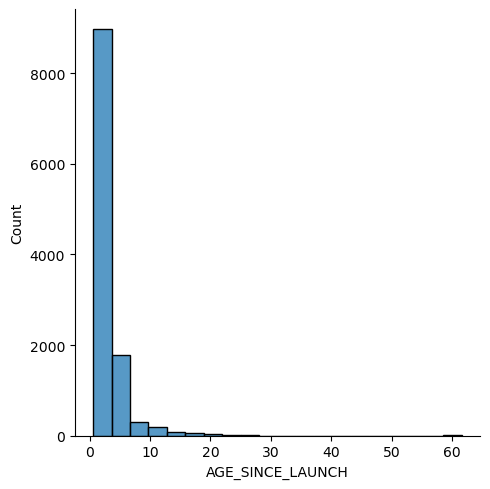

In [63]:
sns.displot(data=df, x = 'AGE_SINCE_LAUNCH', bins = 20)

In [64]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH
0,CALSPHERE 1,1964-063C,2025-07-31 20:36:40.080672,13.761315,0.002491,90.2131,64.4033,177.3590,245.8673,0,...,0.000547,5.420000e-06,0.0,6278.469640,7355.707667,984.707667,7337.382392,7374.032941,7.361332,61.58
1,CALSPHERE 2,1964-063E,2025-07-31 15:15:32.855616,13.528676,0.002053,90.2271,68.2736,79.0754,343.8107,0,...,0.000050,4.200000e-07,0.0,6386.434036,7439.793520,1068.793520,7424.522600,7455.064440,7.319614,61.58
3,TEMPSAT 1,1965-065E,2025-07-31 23:25:04.298016,13.335684,0.007153,89.9758,212.8402,68.5165,309.8791,0,...,0.000054,3.600000e-07,0.0,6478.857782,7511.400059,1140.400059,7457.671014,7565.129103,7.284642,60.58
4,CALSPHERE 4A,1965-065H,2025-07-31 19:27:37.344960,13.362074,0.006773,89.9219,125.3726,288.8275,133.5130,0,...,0.000158,9.000000e-07,0.0,6466.062152,7501.506879,1130.506879,7450.698423,7552.315335,7.289444,60.58
5,OPS 5712 (P/L 160),1967-053A,2025-07-31 22:54:03.988512,14.711843,0.000244,69.9190,99.3721,170.4571,189.6620,0,...,0.001175,7.186000e-05,0.0,5872.819501,7035.360630,664.360630,7033.647520,7037.073741,7.527062,58.58


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11483 entries, 0 to 12290
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   OBJECT_NAME          11483 non-null  object        
 1   OBJECT_ID            11483 non-null  object        
 2   EPOCH                11483 non-null  datetime64[ns]
 3   MEAN_MOTION          11483 non-null  float64       
 4   ECCENTRICITY         11483 non-null  float64       
 5   INCLINATION          11483 non-null  float64       
 6   RA_OF_ASC_NODE       11483 non-null  float64       
 7   ARG_OF_PERICENTER    11483 non-null  float64       
 8   MEAN_ANOMALY         11483 non-null  float64       
 9   EPHEMERIS_TYPE       11483 non-null  int64         
 10  CLASSIFICATION_TYPE  11483 non-null  object        
 11  NORAD_CAT_ID         11483 non-null  int64         
 12  ELEMENT_SET_NO       11483 non-null  int64         
 13  REV_AT_EPOCH         11483 non-null 

----
#### 5. Let's find what type of satellite part it it

In [66]:
# This information is stored as the last digit in the OBJECT_ID column
df['OBJECT_ID']

0        1964-063C
1        1964-063E
3        1965-065E
4        1965-065H
5        1967-053A
           ...    
12286    2025-162G
12287    2025-162H
12288    2025-162J
12289    2025-163A
12290    2025-164A
Name: OBJECT_ID, Length: 11483, dtype: object

In [67]:
# capture anything A-Z as a group
df['SAT_TYPE'] = df['OBJECT_ID'].str.extract(r'([A-Z])$')

In [72]:
df['SAT_TYPE'].value_counts()

SAT_TYPE
A    1107
B     793
C     722
D     637
E     605
F     523
G     490
H     481
J     475
K     453
L     439
M     424
N     415
P     400
Q     397
R     395
V     389
T     379
S     379
U     374
W     369
X     328
Y     284
Z     225
Name: count, dtype: int64